# Ejercicio 3. ¿Se puede reconocer a un Pokémon legendario por sus estadísticas? Un modelo con datos de Kaggle

Curso de Inteligencia Artificial y Minirobots. Capítulo 5, Introducción a las Redes Neuronales Artificiales (José J. Martínez P.)

Ejercicio 5.9, numeral 3: *De la librería de Kaggle para Python, baje un dataset, estudie sus características (features) y su rótulo. Genere un modelo y tome ejemplos de internet y analice los resultados.*

---

## 1. Planteamiento y elección del conjunto de datos

Se usa el conjunto **Pokemon with stats** de Kaggle (`abcsds/pokemon`), que describe los 800 Pokémon de las seis primeras generaciones de la franquicia (1996 a 2013), incluidas sus formas alternativas. Cada fila trae seis estadísticas de combate numéricas y un rótulo binario, `Legendary`, que indica si el Pokémon es legendario.

El conjunto se eligió porque cumple bien las tres partes del enunciado:

- **Características y rótulo claros.** Las seis estadísticas son números enteros con un significado definido, y el rótulo es un dato oficial, no una opinión.
- **Ejemplos genuinamente nuevos en internet.** Entre 2016 y 2022 se publicaron tres generaciones más (7, 8 y 9) que el conjunto no contiene. Sus estadísticas oficiales y su condición de legendario están publicadas en enciclopedias como PokémonDB y Bulbapedia. Eso permite probar el modelo con ejemplos que nunca vio y cuya respuesta correcta se conoce con certeza, que es exactamente lo que pide el ejercicio.
- **Problemas reales de aprendizaje de máquina.** Las clases están muy desbalanceadas (solo 8 % de legendarios), hay filas que son variantes de otras y la pregunta tiene un límite conceptual interesante: la condición de legendario es una decisión narrativa de los creadores del juego, no una propiedad física, y no está claro que las estadísticas basten para deducirla.

La pregunta concreta del ejercicio es: **dadas las seis estadísticas de un Pokémon, ¿es legendario?** Se trata de una clasificación binaria.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, accuracy_score)

tf.keras.utils.set_random_seed(2026)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 140)

## 2. Descarga desde Kaggle

La librería oficial de Kaggle para Python es **`kagglehub`**. Su función `dataset_download` recibe el identificador `usuario/conjunto`, descarga los archivos en una carpeta local y devuelve su ruta. En Google Colab viene preinstalada y los conjuntos públicos se descargan sin configurar credenciales; en una instalación local se instala con `pip install kagglehub`.

Si por alguna razón la descarga falla (sin conexión a Kaggle, por ejemplo), el código lee una copia idéntica del mismo archivo alojada en GitHub. La celda imprime cuál de las dos fuentes se usó, y a continuación se verifica que los datos sean los esperados.

In [2]:
ESTADISTICAS = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]   # las seis estadisticas

try:
    import kagglehub
    ruta = kagglehub.dataset_download("abcsds/pokemon")
    df = pd.read_csv(os.path.join(ruta, "Pokemon.csv"))
    fuente = "Kaggle, via kagglehub (abcsds/pokemon)"
except Exception as e:
    print("No fue posible descargar desde Kaggle:", type(e).__name__)
    df = pd.read_csv("https://raw.githubusercontent.com/KeithGalli/pandas/master/pokemon_data.csv")
    fuente = "copia del mismo archivo de Kaggle alojada en GitHub"

if "Total" not in df.columns:                       # la copia de GitHub omite la columna Total
    df.insert(4, "Total", df[ESTADISTICAS].sum(axis=1))
df["Legendary"] = df["Legendary"].astype(str).str.upper().eq("TRUE").astype(int)

print("Fuente de los datos:", fuente)
print("Filas y columnas:", df.shape)
print("Numero de legendarios:", df["Legendary"].sum())
print("Total = suma de las seis estadisticas en todas las filas:", bool((df["Total"] == df[ESTADISTICAS].sum(axis=1)).all()))
df.head(8)

No fue posible descargar desde Kaggle: ProxyError


Fuente de los datos: copia del mismo archivo de Kaggle alojada en GitHub
Filas y columnas: (800, 13)
Numero de legendarios: 65
Total = suma de las seis estadisticas en todas las filas: True


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,0
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,0
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,0
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,0
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,0


Los valores de control coinciden con la ficha del conjunto en Kaggle: 800 filas y 65 legendarios. La columna `Total` es exactamente la suma de las seis estadísticas.

## 3. Características y rótulo

| Columna | Tipo | Descripción | ¿Se usa como característica? |
|---|---|---|---|
| `#` | entero | número de la Pokédex nacional | No: es un identificador |
| `Name` | texto | nombre (las formas alternativas repiten el nombre base) | No: identificador |
| `Type 1`, `Type 2` | categórica | tipo elemental (Fuego, Agua, Dragón, …); el segundo puede faltar | Se evalúa en la sección 6 |
| `Total` | entero | suma de las seis estadísticas | No: es redundante, combinación lineal de las otras |
| `HP` | entero | puntos de salud | **Sí** |
| `Attack` | entero | ataque físico | **Sí** |
| `Defense` | entero | defensa física | **Sí** |
| `Sp. Atk` | entero | ataque especial | **Sí** |
| `Sp. Def` | entero | defensa especial | **Sí** |
| `Speed` | entero | velocidad | **Sí** |
| `Generation` | entero 1–6 | generación en que apareció | No: los ejemplos nuevos son de las generaciones 7 a 9, fuera del rango |
| `Legendary` | binario | **rótulo** $Y$ | es la salida |

Así, el vector de características es $X = [\text{HP},\ \text{Attack},\ \text{Defense},\ \text{Sp.Atk},\ \text{Sp.Def},\ \text{Speed}]^T$, con $n = 6$, y el rótulo es $Y\in\{0,1\}$.

La exclusión de `Generation` merece una aclaración. Si se incluyera, el modelo vería en los ejemplos nuevos valores de 7, 8 y 9 que nunca aparecieron en el entrenamiento y su respuesta ante ellos sería una extrapolación sin fundamento.

In [3]:
print(df[ESTADISTICAS + ["Total"]].describe().round(1))
print("\nProporcion de clases:")
print(df["Legendary"].value_counts().rename({0: "no legendario", 1: "legendario"}),
      f"\n-> {df['Legendary'].mean():.1%} de legendarios")

          HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Total
count  800.0   800.0    800.0    800.0    800.0  800.0  800.0
mean    69.3    79.0     73.8     72.8     71.9   68.3  435.1
std     25.5    32.5     31.2     32.7     27.8   29.1  120.0
min      1.0     5.0      5.0     10.0     20.0    5.0  180.0
25%     50.0    55.0     50.0     49.8     50.0   45.0  330.0
50%     65.0    75.0     70.0     65.0     70.0   65.0  450.0
75%     80.0   100.0     90.0     95.0     90.0   90.0  515.0
max    255.0   190.0    230.0    194.0    230.0  180.0  780.0

Proporcion de clases:
Legendary
no legendario    735
legendario        65
Name: count, dtype: int64 
-> 8.1% de legendarios


## 4. Exploración de los datos

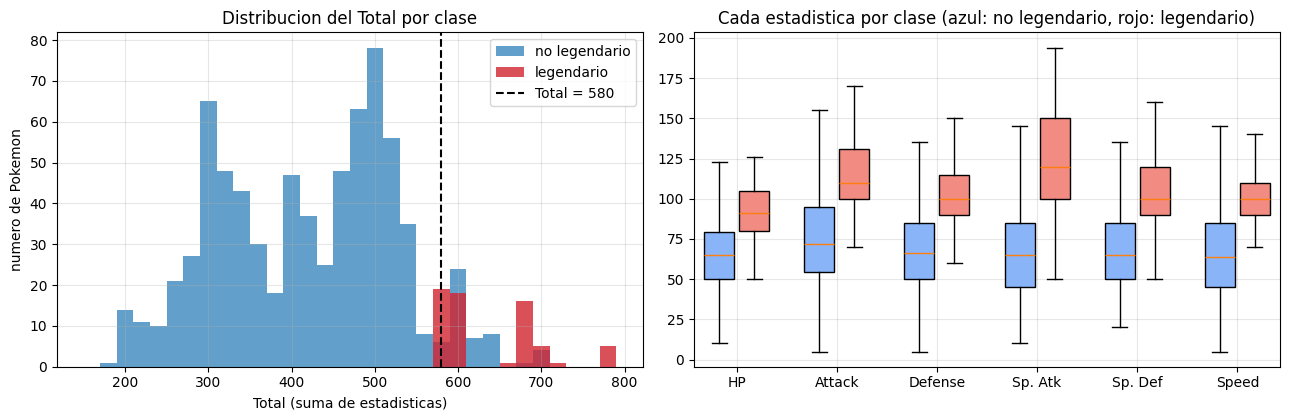

Total minimo entre los legendarios: 580
No legendarios con Total >= 580: 48


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
bins = np.arange(150, 800, 20)
ax[0].hist(df.loc[df.Legendary == 0, "Total"], bins=bins, alpha=0.7, label="no legendario")
ax[0].hist(df.loc[df.Legendary == 1, "Total"], bins=bins, alpha=0.8, label="legendario", color="#d1242f")
ax[0].axvline(580, color="k", ls="--", label="Total = 580")
ax[0].set_xlabel("Total (suma de estadisticas)"); ax[0].set_ylabel("numero de Pokemon"); ax[0].legend()
ax[0].set_title("Distribucion del Total por clase")

datos = [df.loc[df.Legendary == c, s] for s in ESTADISTICAS for c in (0, 1)]
pos = [i + d for i in range(0, 12, 2) for d in (0, 0.7)]
bp = ax[1].boxplot(datos, positions=pos, widths=0.6, patch_artist=True, showfliers=False)
for j, caja in enumerate(bp["boxes"]):
    caja.set_facecolor("#8ab4f8" if j % 2 == 0 else "#f28b82")
ax[1].set_xticks([i + 0.35 for i in range(0, 12, 2)]); ax[1].set_xticklabels(ESTADISTICAS)
ax[1].set_title("Cada estadistica por clase (azul: no legendario, rojo: legendario)")
plt.tight_layout(); plt.show()

print("Total minimo entre los legendarios:", df.loc[df.Legendary == 1, "Total"].min())
print("No legendarios con Total >= 580:", int(((df.Legendary == 0) & (df.Total >= 580)).sum()))

La exploración muestra dos cosas.

Primero, **todos los legendarios del conjunto tienen un Total de al menos 580**, y los no legendarios se concentran por debajo. Esto sugiere un clasificador trivial, "legendario si Total ≥ 580", que servirá de punto de comparación: una red neuronal solo se justifica si mejora a una regla que cualquiera escribiría mirando el histograma.

Segundo, hay **una cola de no legendarios con Total alto**. Examinarla lleva al principal problema de calidad de los datos.

## 5. Calidad de los datos: las formas alternativas

El conjunto incluye como filas separadas las **megaevoluciones** y **regresiones primigenias**, que son transformaciones temporales de un Pokémon existente durante una batalla. Por ejemplo, `CharizardMega Charizard X` aparece como una fila adicional a `Charizard`.

In [5]:
es_forma = df["Name"].str.contains("Mega ") | df["Name"].str.contains("Primal")
formas = df[es_forma]
print("Filas que son megaevolucion o regresion primigenia:", len(formas))
print("   de ellas, legendarias:", int(formas.Legendary.sum()), "  no legendarias:", int((formas.Legendary == 0).sum()))
print("   no legendarias con Total >= 580:", int(((formas.Legendary == 0) & (formas.Total >= 580)).sum()),
      "de los", int(((df.Legendary == 0) & (df.Total >= 580)).sum()), "no legendarios con Total >= 580 del conjunto")
print()
print(formas.loc[formas.Legendary == 0, ["Name", "Total", "Legendary"]].sort_values("Total", ascending=False).head(8).to_string(index=False))

Filas que son megaevolucion o regresion primigenia: 50
   de ellas, legendarias: 8   no legendarias: 42
   no legendarias con Total >= 580: 31 de los 48 no legendarios con Total >= 580 del conjunto

                     Name  Total  Legendary
  SalamenceMega Salamence    700          0
  TyranitarMega Tyranitar    700          0
  MetagrossMega Metagross    700          0
    GarchompMega Garchomp    700          0
    GyaradosMega Gyarados    640          0
    SwampertMega Swampert    635          0
CharizardMega Charizard X    634          0
CharizardMega Charizard Y    634          0


Hay 50 filas de formas alternativas. Casi todos los no legendarios con Total alto son en realidad **megaevoluciones de Pokémon comunes** (Mega Garchomp, Mega Tyranitar, Mega Salamence, …), a las que el juego sube artificialmente las estadísticas en unos 100 puntos. Para el objetivo del ejercicio estas filas son ruido, por dos razones:

- no son especies distintas sino estados temporales de una especie que ya está en el conjunto, así que duplican información;
- introducen ejemplos con estadísticas de legendario y rótulo de no legendario, contradictorios con el patrón que el modelo debe aprender. Los ejemplos de internet que se usarán después son, todos, formas base.

Se construye por lo tanto una versión limpia sin esas 50 filas. En la sección 6 se mide si la limpieza mejora o no el modelo, en lugar de suponerlo.

In [6]:
limpio = df[~es_forma].reset_index(drop=True)
print("Conjunto limpio:", limpio.shape[0], "Pokemon,", int(limpio.Legendary.sum()), "legendarios",
      f"({limpio.Legendary.mean():.1%})")
print("No legendarios con Total >= 580 tras la limpieza:", int(((limpio.Legendary == 0) & (limpio.Total >= 580)).sum()))

Conjunto limpio: 750 Pokemon, 57 legendarios (7.6%)
No legendarios con Total >= 580 tras la limpieza: 17


### 5.1 Calidad de los datos: el rótulo

Al revisar los errores de un primer modelo aparecieron Celebi y Keldeo, clasificados como legendarios por la red pero rotulados como no legendarios en el conjunto. Ambos son **Pokémon míticos**, una categoría oficial tan especial como la de legendario. El problema es que el conjunto no la trata de forma consistente: Jirachi, Darkrai o Arceus, que también son míticos, sí aparecen como legendarios.

Para decidir con un criterio explícito, se contrastó la columna `Legendary` con las listas oficiales de legendarios y míticos de las generaciones 1 a 6 publicadas en Bulbapedia. Se adopta como definición del rótulo **"legendario o mítico"**, que es la que usa el propio conjunto en la mayoría de los casos.

In [7]:
LEGENDARIOS = ["Articuno", "Zapdos", "Moltres", "Mewtwo", "Raikou", "Entei", "Suicune", "Lugia", "Ho-oh",
               "Regirock", "Regice", "Registeel", "Latias", "Latios", "Kyogre", "Groudon", "Rayquaza",
               "Uxie", "Mesprit", "Azelf", "Dialga", "Palkia", "Heatran", "Regigigas", "Giratina", "Cresselia",
               "Cobalion", "Terrakion", "Virizion", "Tornadus", "Thundurus", "Landorus", "Reshiram", "Zekrom",
               "Kyurem", "Xerneas", "Yveltal", "Zygarde"]
MITICOS = ["Mew", "Celebi", "Jirachi", "Deoxys", "Phione", "Manaphy", "Darkrai", "Shaymin", "Arceus",
           "Victini", "Keldeo", "Meloetta", "Genesect", "Diancie", "Hoopa", "Volcanion"]

# En el archivo, las formas se escriben pegadas al nombre: "KeldeoOrdinary Forme", "Zygarde50% Forme"
nombre_base = df["Name"].str.replace(r"(?<=[a-z])(?=[A-Z0-9]).*$", "", regex=True)
oficial = nombre_base.isin(LEGENDARIOS + MITICOS).astype(int)

discrepancias = df[oficial != df["Legendary"]].assign(Oficial=oficial[oficial != df["Legendary"]],
                                                      Categoria=nombre_base.map(lambda n: "mitico" if n in MITICOS else "legendario"))
print(f"Filas cuyo rotulo de Kaggle no coincide con las listas oficiales: {len(discrepancias)}")
print(discrepancias[["Name", "Total", "Categoria", "Legendary", "Oficial"]].to_string(index=False))

df["Legendary_kaggle"] = df["Legendary"]
df["Legendary"] = oficial
limpio = df[~es_forma].reset_index(drop=True)
print(f"\nConjunto limpio con rotulo corregido: {len(limpio)} Pokemon, {int(limpio.Legendary.sum())} legendarios o miticos "
      f"({limpio.Legendary.mean():.1%})")
print("Legendarios o miticos con Total < 580 tras la correccion:",
      limpio.loc[(limpio.Legendary == 1) & (limpio.Total < 580), "Name"].tolist())

Filas cuyo rotulo de Kaggle no coincide con las listas oficiales: 10
                   Name  Total  Categoria  Legendary  Oficial
                    Mew    600     mitico          0        1
                 Celebi    600     mitico          0        1
              Cresselia    600 legendario          0        1
                 Phione    480     mitico          0        1
                Manaphy    600     mitico          0        1
   KeldeoOrdinary Forme    580     mitico          0        1
   KeldeoResolute Forme    580     mitico          0        1
     MeloettaAria Forme    600     mitico          0        1
MeloettaPirouette Forme    600     mitico          0        1
               Genesect    600     mitico          0        1

Conjunto limpio con rotulo corregido: 750 Pokemon, 67 legendarios o miticos (8.9%)
Legendarios o miticos con Total < 580 tras la correccion: ['Phione']


Diez filas, de ocho especies, tienen el rótulo equivocado según la definición adoptada: siete especies míticas (Mew, Celebi, Phione, Manaphy, Keldeo, Meloetta y Genesect; Keldeo y Meloetta tienen dos formas cada una) y una legendaria, Cresselia. En todos los casos el error va en la misma dirección: Pokémon legendarios o míticos marcados como comunes. Son **errores de rótulo**, y su efecto es enseñarle al modelo que perfiles de legendario (Mew, Celebi y Manaphy tienen las seis estadísticas en 100) corresponden a Pokémon comunes.

Tras la corrección aparece además el primer legendario con Total menor que 580, Phione, de modo que la regla del Total deja de tener sensibilidad perfecta.

## 6. Selección del modelo por validación cruzada

Con entre 57 y 67 legendarios según la variante, un único conjunto de prueba de 120 ejemplos contendría unos 10, y cada acierto o error movería las métricas varios puntos. Para comparar opciones de forma confiable se usa **validación cruzada estratificada de 5 particiones**: los datos se dividen en 5 partes con la misma proporción de clases, se entrena con 4 y se evalúa con la quinta, y se rota hasta que cada parte haya sido de evaluación una vez. Se reporta el promedio.

**Arquitectura común.** Red 6‑16‑8‑1: dos capas ocultas con ReLU y una neurona de salida con **sigmoide**, cuya salida se interpreta como la probabilidad de que el Pokémon sea legendario. Es la misma estructura del capítulo con una sola clase de salida.

**Métricas.** Con 92 % de no legendarios, un modelo que responda siempre "no legendario" tiene 92 % de exactitud sin haber aprendido nada. Por eso se usan métricas que se fijan en la clase minoritaria:

- **Precisión**: de los Pokémon que el modelo llama legendarios, qué fracción lo es.
- **Sensibilidad** (*recall*): de los legendarios reales, qué fracción detecta.
- **F1**: media armónica de las dos anteriores; resume el desempeño en un solo número.
- **AUC**: área bajo la curva ROC; mide qué tan bien ordena el modelo a los legendarios por encima de los demás, sin depender del umbral de 0.5.

Se comparan cuatro variantes que acumulan las decisiones de preparación de datos, siempre contra la regla Total ≥ 580. La celda tarda uno o dos minutos.

In [8]:
def crea_red(n_entradas, semilla):
    tf.keras.utils.set_random_seed(semilla)
    red = tf.keras.Sequential([
        tf.keras.Input(shape=(n_entradas,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    red.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="binary_crossentropy")
    return red

def pesos_de_clase(y):
    "Pesa cada legendario tanto como (no legendarios / legendarios) para compensar el desbalance."
    return {0: 1.0, 1: float((y == 0).sum() / (y == 1).sum())}

def metricas(y, p, umbral=0.5):
    c = (p >= umbral).astype(int)
    return [precision_score(y, c, zero_division=0), recall_score(y, c), f1_score(y, c), roc_auc_score(y, p)]

def validacion_cruzada(datos, columnas):
    X = datos[columnas].values.astype(float); y = datos["Legendary"].values
    red_m, regla_m = [], []
    for k, (tr, te) in enumerate(StratifiedKFold(5, shuffle=True, random_state=0).split(X, y)):
        esc = StandardScaler().fit(X[tr])
        red = crea_red(len(columnas), semilla=k)
        red.fit(esc.transform(X[tr]), y[tr], epochs=150, batch_size=32,
                class_weight=pesos_de_clase(y[tr]), verbose=0)
        red_m.append(metricas(y[te], red.predict(esc.transform(X[te]), verbose=0).ravel()))
        regla_m.append(metricas(y[te], (datos["Total"].values[te] >= 580).astype(float)))
    return np.mean(red_m, axis=0), np.mean(regla_m, axis=0)

tipos = sorted(set(df["Type 1"]) | set(df["Type 2"].dropna()))
def con_tipos(d):
    d = d.copy()
    for t in tipos:
        d["T_" + t] = ((d["Type 1"] == t) | (d["Type 2"] == t)).astype(int)
    return d
COLS_TIPOS = ESTADISTICAS + ["T_" + t for t in tipos]

original = df.assign(Legendary=df["Legendary_kaggle"])
sin_formas_rot_kaggle = original[~es_forma].reset_index(drop=True)
variantes = [("A. Datos originales de Kaggle",        original,              ESTADISTICAS),
             ("B. A sin formas alternativas",         sin_formas_rot_kaggle, ESTADISTICAS),
             ("C. B con rotulo corregido",            limpio,                ESTADISTICAS),
             ("D. C + 18 variables de tipo",          con_tipos(limpio),     COLS_TIPOS)]

print(f"{'Variante':<36}{'Modelo':<14}{'Precision':>10}{'Sensib.':>9}{'F1':>7}{'AUC':>7}")
print("-" * 83)
for nombre, datos, cols in variantes:
    m_red, m_regla = validacion_cruzada(datos, cols)
    print(f"{nombre:<36}{'red neuronal':<14}" + "".join(f"{v:>9.3f}" if i else f"{v:>10.3f}" for i, v in enumerate(m_red)))
    print(f"{'':<36}{'Total >= 580':<14}" + "".join(f"{v:>9.3f}" if i else f"{v:>10.3f}" for i, v in enumerate(m_regla[:3])) + f"{'--':>7}")

Variante                            Modelo         Precision  Sensib.     F1    AUC
-----------------------------------------------------------------------------------


A. Datos originales de Kaggle       red neuronal       0.588    0.738    0.646    0.963
                                    Total >= 580       0.582    1.000    0.734     --


B. A sin formas alternativas        red neuronal       0.774    0.858    0.811    0.979
                                    Total >= 580       0.771    1.000    0.870     --


C. B con rotulo corregido           red neuronal       0.792    0.821    0.799    0.976
                                    Total >= 580       0.897    0.985    0.937     --


D. C + 18 variables de tipo         red neuronal       0.738    0.729    0.728    0.955
                                    Total >= 580       0.897    0.985    0.937     --


**`StandardScaler`** transforma cada característica restándole su media y dividiéndola por su desviación estándar, calculadas **solo con los datos de entrenamiento** de cada partición. Cumple el mismo papel que la división por 255 del Ejercicio 2: lleva todas las entradas a una escala comparable. Se ajusta solo con entrenamiento para que la evaluación no use información de los datos de prueba.

**`class_weight`** hace que, en la función de pérdida, cada error sobre un legendario pese unas 10 veces más que un error sobre un no legendario. Sin esto, la red tiende a la solución perezosa de predecir casi siempre "no legendario".

La tabla permite tomar tres decisiones con evidencia:

1. **Quitar las formas alternativas mejora mucho la red**: su F1 pasa de 0.65 a 0.81 (variante A frente a B). La regla también mejora, lo que confirma que esas filas eran ruido.
2. **Corregir el rótulo favorece sobre todo a la regla.** Su F1 sube de 0.87 a 0.94, porque los diez casos corregidos son míticos y legendarios con Total entre 580 y 600, que la regla ya marcaba como legendarios y antes contaban como falsos positivos. La red queda prácticamente igual (0.81 frente a 0.80): gana precisión y pierde algo de sensibilidad. La corrección se mantiene de todos modos, porque se trata de datos equivocados y no de una opción de modelado. La variante C es la que se usa en adelante.
3. **Agregar los tipos empeora el modelo** (el F1 baja de 0.80 a 0.73). Son 18 columnas binarias que, con tan pocos legendarios, la red usa para memorizar casos particulares.

Queda un resultado que conviene decir sin rodeos: **con los datos de Kaggle, la regla Total ≥ 580 supera a la red en F1** (0.94 frente a 0.80). En las seis primeras generaciones el Total separa las clases casi a la perfección, y ningún modelo puede mejorar mucho a partir de ahí. La red ordena bien a los Pokémon (AUC de 0.98) pero produce más falsas alarmas. Qué tan bien generaliza cada uno a Pokémon nuevos no se puede saber con estos datos; para eso sirven los ejemplos de internet de la sección 8.

## 7. Modelo final

Se entrena el modelo con la mejor variante (sin formas alternativas, 6 estadísticas). Ahora se usa la división de la sección 5.4 del capítulo en entrenamiento (70 %), validación (15 %) y prueba (15 %), estratificada para que las tres partes conserven la proporción de legendarios. La validación se usa para la parada temprana.

Entrenamiento: 524 (47 legendarios)   Validacion: 113 (10)   Prueba: 113 (10)

Medias usadas para escalar: {'HP': np.float64(69.2), 'Attack': np.float64(75.9), 'Defense': np.float64(71.0), 'Sp. Atk': np.float64(70.2), 'Sp. Def': np.float64(69.1), 'Speed': np.float64(66.6)}
Desviaciones:               {'HP': np.float64(26.4), 'Attack': np.float64(29.3), 'Defense': np.float64(28.4), 'Sp. Atk': np.float64(29.4), 'Sp. Def': np.float64(25.8), 'Speed': np.float64(27.9)}


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento detenido en la epoca 39; se restauraron los pesos de la epoca 9


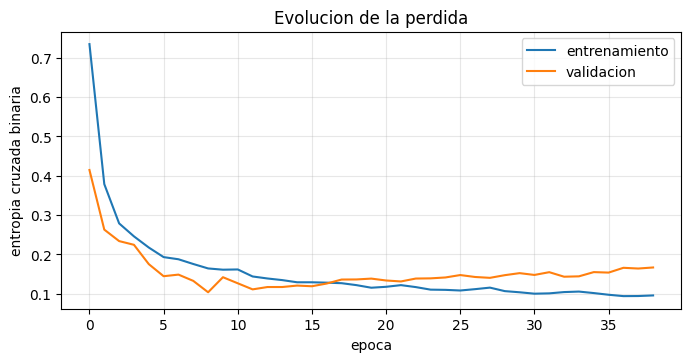

In [9]:
X_all = limpio[ESTADISTICAS].values.astype(float)
y_all = limpio["Legendary"].values
X_tr, X_te, y_tr, y_te, i_tr, i_te = train_test_split(X_all, y_all, np.arange(len(y_all)),
                                                      test_size=0.15, stratify=y_all, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.1765, stratify=y_tr, random_state=42)
print(f"Entrenamiento: {len(y_tr)} ({y_tr.sum()} legendarios)   Validacion: {len(y_va)} ({y_va.sum()})   "
      f"Prueba: {len(y_te)} ({y_te.sum()})")

escala = StandardScaler().fit(X_tr)
print("\nMedias usadas para escalar:", dict(zip(ESTADISTICAS, escala.mean_.round(1))))
print("Desviaciones:              ", dict(zip(ESTADISTICAS, escala.scale_.round(1))))

modelo = crea_red(6, semilla=2026)
modelo.summary()
parada = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
hist = modelo.fit(escala.transform(X_tr), y_tr, epochs=400, batch_size=32,
                  validation_data=(escala.transform(X_va), y_va),
                  class_weight=pesos_de_clase(y_tr), callbacks=[parada], verbose=0)
print(f"Entrenamiento detenido en la epoca {len(hist.history['loss'])}; "
      f"se restauraron los pesos de la epoca {int(np.argmin(hist.history['val_loss'])) + 1}")

plt.figure(figsize=(8, 3.6))
plt.plot(hist.history["loss"], label="entrenamiento"); plt.plot(hist.history["val_loss"], label="validacion")
plt.xlabel("epoca"); plt.ylabel("entropia cruzada binaria"); plt.legend(); plt.title("Evolucion de la perdida")
plt.show()

La red tiene $6\cdot16+16 = 112$, $16\cdot8+8 = 136$ y $8+1 = 9$ parámetros por capa, 257 en total. Es una red pequeña, acorde con las 524 filas de entrenamiento: una red mucho más grande tendría más parámetros que ejemplos y sobreentrenaría.

La pérdida usada es la **entropía cruzada binaria**, $E = -[y\ln p + (1-y)\ln(1-p)]$, que es la versión de dos clases de la usada en el Ejercicio 2.

### 7.1 Evaluación en el conjunto de prueba

In [10]:
p_te = modelo.predict(escala.transform(X_te), verbose=0).ravel()
regla_te = (X_te.sum(axis=1) >= 580).astype(int)
siempre_no = np.zeros_like(y_te)

print(f"{'Clasificador':<26}{'Exactitud':>10}{'Precision':>11}{'Sensib.':>9}{'F1':>7}")
print("-" * 63)
for nombre, pred in (("Siempre 'no legendario'", siempre_no),
                     ("Regla Total >= 580", regla_te),
                     ("Red neuronal", (p_te >= 0.5).astype(int))):
    print(f"{nombre:<26}{accuracy_score(y_te, pred):>10.3f}{precision_score(y_te, pred, zero_division=0):>11.3f}"
          f"{recall_score(y_te, pred):>9.3f}{f1_score(y_te, pred):>7.3f}")
print(f"\nAUC de la red en prueba: {roc_auc_score(y_te, p_te):.3f}")

tn, fp, fn, tp = confusion_matrix(y_te, p_te >= 0.5).ravel()
print(f"\nMatriz de confusion de la red:  VN={tn}  FP={fp}  FN={fn}  VP={tp}")
errores = limpio.iloc[i_te][(p_te >= 0.5) != (y_te == 1)].assign(prob=p_te[(p_te >= 0.5) != (y_te == 1)])
print("\nErrores de la red en prueba:")
print(errores[["Name", "Total"] + ESTADISTICAS + ["Legendary", "prob"]].round(3).to_string(index=False))

Clasificador               Exactitud  Precision  Sensib.     F1
---------------------------------------------------------------
Siempre 'no legendario'        0.912      0.000    0.000  0.000
Regla Total >= 580             0.991      0.909    1.000  0.952
Red neuronal                   0.947      0.625    1.000  0.769

AUC de la red en prueba: 0.998

Matriz de confusion de la red:  VN=97  FP=6  FN=0  VP=10

Errores de la red en prueba:
     Name  Total  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Legendary  prob
  Delphox    534  75      69       72      114      100    104          0 0.614
  Umbreon    525  95      65      110       60      130     65          0 0.861
Vanilluxe    535  71      95       85      110       95     79          0 0.525
Porygon-Z    535  85      80       70      135       75     90          0 0.619
   Goodra    600  90     100       70      110      150     80          0 0.912
 Arcanine    555  90     110       80      100       80     95          0 0.824


La primera fila de la tabla ilustra por qué la exactitud no sirve aquí: el clasificador que nunca detecta un legendario tiene una exactitud del 92 %.

Con 10 legendarios en prueba, cada uno vale 10 puntos de sensibilidad, así que estas cifras deben leerse junto con las de la validación cruzada. En prueba se repite el patrón: la red encuentra a los 10 legendarios pero marca además a 6 Pokémon comunes, mientras que la regla se equivoca una sola vez. Los falsos positivos de la red son Pokémon comunes con Totales entre 525 y 600, varios de ellos con ataque especial alto (Delphox, Vanilluxe, Porygon‑Z, Goodra). La sección 9 examina por qué.

### 7.2 Ajuste del umbral de decisión

Los pesos de clase hacen que la red penalice mucho más perder un legendario que dar una falsa alarma, así que sus probabilidades quedan sesgadas hacia arriba y el umbral de 0.5 resulta demasiado permisivo. Es un efecto conocido de `class_weight`. El umbral es un hiperparámetro más, así que se elige con el conjunto de **validación**, nunca con el de prueba: se prueban umbrales de 0.05 a 0.95 y se toma el centro del intervalo con mayor F1 en validación.

In [11]:
p_va = modelo.predict(escala.transform(X_va), verbose=0).ravel()
umbrales = np.round(np.arange(0.05, 0.96, 0.05), 2)
f1_va = np.array([f1_score(y_va, p_va >= u) for u in umbrales])
mejores = umbrales[f1_va == f1_va.max()]
UMBRAL = float(np.round(np.median(mejores), 2))
print(f"F1 maximo en validacion: {f1_va.max():.3f}, alcanzado con umbrales de {mejores.min()} a {mejores.max()}")
print(f"Umbral elegido: {UMBRAL}")

print(f"\n{'Red neuronal en prueba':<26}{'Precision':>11}{'Sensib.':>9}{'F1':>7}{'FP':>5}{'FN':>5}")
for u in (0.5, UMBRAL):
    c = (p_te >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, c).ravel()
    print(f"{'umbral ' + str(u):<26}{precision_score(y_te, c):>11.3f}{recall_score(y_te, c):>9.3f}{f1_score(y_te, c):>7.3f}{fp:>5}{fn:>5}")

F1 maximo en validacion: 0.833, alcanzado con umbrales de 0.4 a 0.4
Umbral elegido: 0.4

Red neuronal en prueba      Precision  Sensib.     F1   FP   FN
umbral 0.5                      0.625    1.000  0.769    6    0
umbral 0.4                      0.625    1.000  0.769    6    0


**Resultado del ajuste.** La validación sugiere un umbral de 0.4, más bajo que 0.5, y en prueba el resultado no cambia: los seis falsos positivos tienen probabilidades entre 0.52 y 0.91. Con solo 10 legendarios, el conjunto de validación no tiene información suficiente para afinar el umbral, y las falsas alarmas no se deben a un umbral mal puesto sino a lo que la red aprendió. Se conserva el umbral elegido por coherencia con el procedimiento; no altera ninguna conclusión.

## 8. Ejemplos tomados de internet

Se tomaron de PokémonDB (`pokemondb.net/pokedex/<nombre>`) y se contrastaron con Bulbapedia las estadísticas base oficiales de 23 Pokémon de las generaciones 7, 8 y 9, ninguno de los cuales está en el conjunto de Kaggle. Se escogieron para cubrir las categorías que ponen a prueba el modelo:

| Categoría | Rótulo real | Qué pone a prueba |
|---|:-:|---|
| Legendarios "de portada" | 1 | el caso típico: estadísticas muy altas |
| Legendarios menores y míticos | 1 | legendarios con estadísticas de rango medio |
| Legendarios en etapa inicial (Cosmog, Kubfu) | 1 | legendarios con estadísticas bajas |
| Pseudolegendarios | 0 | no legendarios con Total de 600, igual que muchos legendarios |
| Ultraentes y Paradojas | 0 | Pokémon "especiales" que oficialmente no son legendarios |
| Pokémon comunes | 0 | el caso típico negativo |

Para Zacian se usa su forma base (*Guerrero Avezado*), no la forma *Espada Suprema*.

In [12]:
internet = pd.DataFrame([
    # nombre,        gen, categoria,                    HP, Atk, Def, SpA, SpD, Spe, legendario
    ("Solgaleo",       7, "Legendario de portada",     137, 137, 107, 113,  89,  97, 1),
    ("Zacian",         8, "Legendario de portada",      92, 120, 115,  80, 115, 138, 1),
    ("Eternatus",      8, "Legendario de portada",     140,  85,  95, 145,  95, 130, 1),
    ("Koraidon",       9, "Legendario de portada",     100, 135, 115,  85, 100, 135, 1),
    ("Miraidon",       9, "Legendario de portada",     100,  85, 100, 135, 115, 135, 1),
    ("Tapu Koko",      7, "Legendario menor",           70, 115,  85,  95,  75, 130, 1),
    ("Ting-Lu",        9, "Legendario menor",          155, 110, 125,  55,  80,  45, 1),
    ("Zeraora",        7, "Mitico",                     88, 112,  75, 102,  80, 143, 1),
    ("Calyrex",        8, "Legendario menor",          100,  80,  80,  80,  80,  80, 1),
    ("Kubfu",          8, "Legendario etapa inicial",   60,  90,  60,  53,  50,  72, 1),
    ("Cosmog",         7, "Legendario etapa inicial",   43,  29,  31,  29,  31,  37, 1),
    ("Dragapult",      8, "Pseudolegendario",           88, 120,  75, 100,  75, 142, 0),
    ("Baxcalibur",     9, "Pseudolegendario",          115, 145,  92,  75,  86,  87, 0),
    ("Kommo-o",        7, "Pseudolegendario",           75, 110, 125, 100, 105,  85, 0),
    ("Buzzwole",       7, "Ultraente",                 107, 139, 139,  53,  53,  79, 0),
    ("Great Tusk",     9, "Paradoja",                  115, 131, 131,  53,  53,  87, 0),
    ("Kingambit",      9, "Comun",                     100, 135, 120,  60,  85,  50, 0),
    ("Gholdengo",      9, "Comun",                      87,  60,  95, 133,  91,  84, 0),
    ("Decidueye",      7, "Comun",                      78, 107,  75, 100, 100,  70, 0),
    ("Corviknight",    8, "Comun",                      98,  87, 105,  53,  85,  67, 0),
    ("Toxapex",        7, "Comun",                      50,  63, 152,  53, 142,  35, 0),
    ("Mimikyu",        7, "Comun",                      55,  90,  80,  50, 105,  96, 0),
    ("Wooloo",         8, "Comun",                      42,  40,  55,  40,  45,  48, 0),
], columns=["Name", "Gen", "Categoria"] + ESTADISTICAS + ["Legendary"])
internet.insert(3, "Total", internet[ESTADISTICAS].sum(axis=1))
internet["Fuente"] = "https://pokemondb.net/pokedex/" + internet["Name"].str.lower().str.replace(" ", "-")

internet["p_red"] = modelo.predict(escala.transform(internet[ESTADISTICAS].values.astype(float)), verbose=0).ravel()
internet["red"]   = (internet["p_red"] >= 0.5).astype(int)
internet["red_u"] = (internet["p_red"] >= UMBRAL).astype(int)
internet["regla"] = (internet["Total"] >= 580).astype(int)

print(f"Columnas: red = red con umbral 0.5, red_u = red con umbral {UMBRAL}, regla = Total >= 580\n")
print(internet[["Name", "Gen", "Categoria", "Total", "Legendary", "p_red", "red", "red_u", "regla"]].round(3).to_string(index=False))

Columnas: red = red con umbral 0.5, red_u = red con umbral 0.4, regla = Total >= 580

       Name  Gen                Categoria  Total  Legendary  p_red  red  red_u  regla
   Solgaleo    7    Legendario de portada    680          1  0.993    1      1      1
     Zacian    8    Legendario de portada    660          1  1.000    1      1      1
  Eternatus    8    Legendario de portada    690          1  0.999    1      1      1
   Koraidon    9    Legendario de portada    670          1  1.000    1      1      1
   Miraidon    9    Legendario de portada    670          1  1.000    1      1      1
  Tapu Koko    7         Legendario menor    570          1  0.957    1      1      0
    Ting-Lu    9         Legendario menor    570          1  0.002    0      0      0
    Zeraora    7                   Mitico    600          1  0.973    1      1      1
    Calyrex    8         Legendario menor    500          1  0.050    0      0      0
      Kubfu    8 Legendario etapa inicial    385      

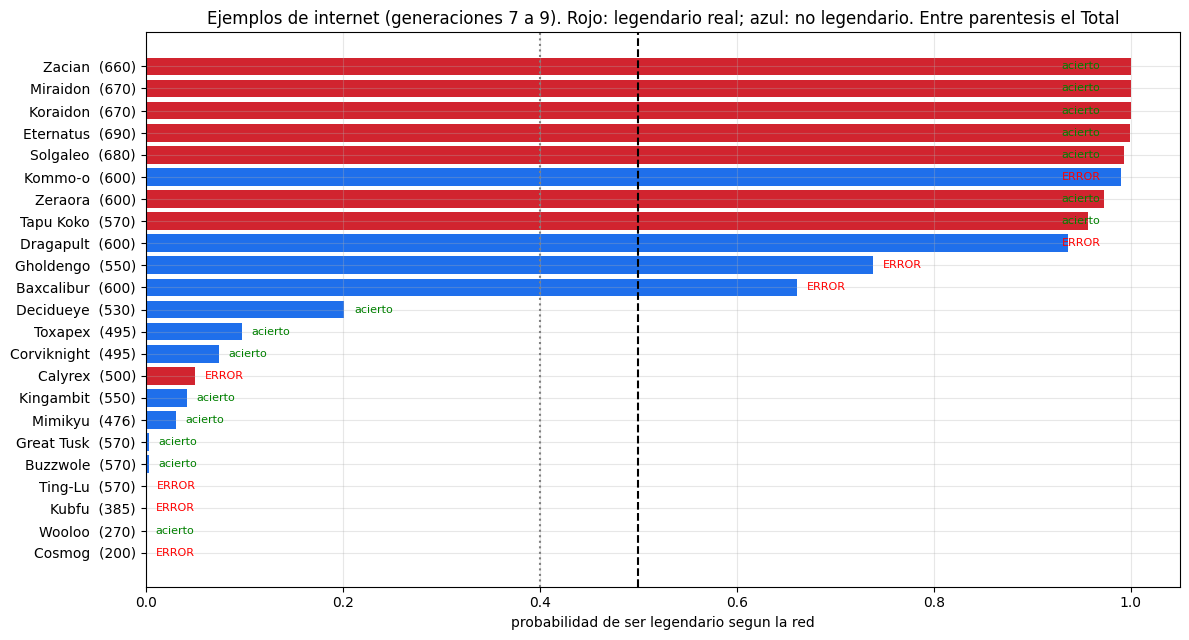

Clasificador            Aciertos  Precision  Sensib.     F1
Red, umbral 0.5            15/23      0.636    0.636  0.636
Red, umbral 0.4            15/23      0.636    0.636  0.636
Regla Total >= 580         15/23      0.667    0.545  0.600


In [13]:
fig, ax = plt.subplots(figsize=(12, 6.5))
orden = internet.sort_values("p_red")
colores = ["#d1242f" if y == 1 else "#1f6feb" for y in orden["Legendary"]]
ax.barh(orden["Name"] + "  (" + orden["Total"].astype(str) + ")", orden["p_red"], color=colores)
ax.axvline(0.5, color="k", ls="--"); ax.axvline(UMBRAL, color="gray", ls=":")
for i, (_, r) in enumerate(orden.iterrows()):
    ok = r["red"] == r["Legendary"]
    ax.text(min(r["p_red"] + 0.01, 0.93), i, "acierto" if ok else "ERROR", va="center", fontsize=8,
            color="green" if ok else "red")
ax.set_xlim(0, 1.05); ax.set_xlabel("probabilidad de ser legendario segun la red")
ax.set_title("Ejemplos de internet (generaciones 7 a 9). Rojo: legendario real; azul: no legendario. Entre parentesis el Total")
plt.tight_layout(); plt.show()

print(f"{'Clasificador':<22}{'Aciertos':>10}{'Precision':>11}{'Sensib.':>9}{'F1':>7}")
for nombre, col in (("Red, umbral 0.5", "red"), (f"Red, umbral {UMBRAL}", "red_u"), ("Regla Total >= 580", "regla")):
    y, c = internet["Legendary"], internet[col]
    print(f"{nombre:<22}{(y == c).sum():>7}/23{precision_score(y, c):>11.3f}{recall_score(y, c):>9.3f}{f1_score(y, c):>7.3f}")

## 9. Análisis de los resultados con los ejemplos de internet

El análisis se organiza por categoría, porque los errores no son aleatorios: cada grupo revela algo distinto sobre lo que el modelo aprendió.

                            n  Total medio  aciertos red 0.5  aciertos red umbral  aciertos regla
Categoria                                                                                        
Legendario de portada     5.0   674.000000               5.0                  5.0             5.0
Legendario menor          3.0   546.666667               1.0                  1.0             0.0
Mitico                    1.0   600.000000               1.0                  1.0             1.0
Legendario etapa inicial  2.0   292.500000               0.0                  0.0             0.0
Pseudolegendario          3.0   600.000000               0.0                  0.0             0.0
Ultraente                 1.0   570.000000               1.0                  1.0             1.0
Paradoja                  1.0   570.000000               1.0                  1.0             1.0
Comun                     7.0   480.857143               6.0                  6.0             7.0

En el conjunto de K

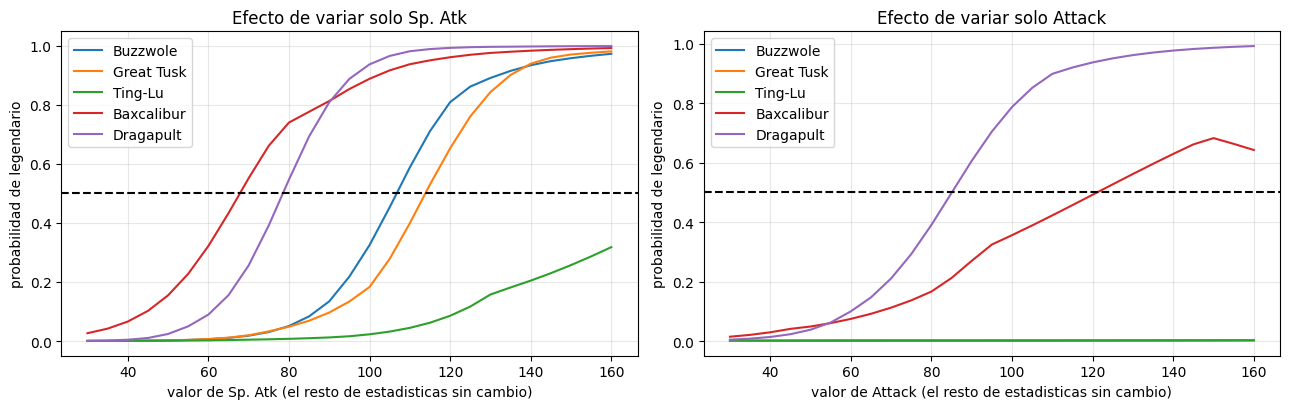

Probabilidad con el Sp. Atk real y si su Sp. Atk fuera 110 (manteniendo lo demas):
   Buzzwole    Sp. Atk= 53: p=0.003    Sp. Atk=110: p=0.588
   Great Tusk  Sp. Atk= 53: p=0.003    Sp. Atk=110: p=0.399
   Ting-Lu     Sp. Atk= 55: p=0.002    Sp. Atk=110: p=0.045


   Kingambit   Sp. Atk= 60: p=0.041    Sp. Atk=110: p=0.206
   Baxcalibur  Sp. Atk= 75: p=0.661    Sp. Atk=110: p=0.937


In [14]:
resumen = internet.groupby("Categoria", sort=False).apply(
    lambda g: pd.Series({"n": len(g), "Total medio": g.Total.mean(),
                         "aciertos red 0.5": int((g.red == g.Legendary).sum()),
                         "aciertos red umbral": int((g.red_u == g.Legendary).sum()),
                         "aciertos regla": int((g.regla == g.Legendary).sum())}), include_groups=False)
print(resumen.to_string())

# 1) Los ejemplos de internet, estan dentro de la region que la red conocio en entrenamiento?
fuertes = limpio[limpio.Total >= 550]
print(f"\nEn el conjunto de Kaggle (limpio) hay {len(fuertes)} Pokemon con Total >= 550.")
print("Valor minimo de cada estadistica entre ellos:")
print(fuertes[ESTADISTICAS].min().to_string())
print("\nEjemplos de internet con Total >= 550 que tienen alguna estadistica por debajo de ese minimo:")
minimos = fuertes[ESTADISTICAS].min()
for _, r in internet[internet.Total >= 550].iterrows():
    fuera = [f"{e}={r[e]} (min {minimos[e]})" for e in ESTADISTICAS if r[e] < minimos[e]]
    if fuera:
        print(f"   {r['Name']:<11} p={r['p_red']:.3f}  real={r['Legendary']}  ->  " + ", ".join(fuera))

print("\nMediana de cada estadistica entre los Pokemon con Total >= 550, por clase:")
print(fuertes.groupby("Legendary")[ESTADISTICAS].median().rename(index={0: "no legendario", 1: "legendario/mitico"}).to_string())

# 2) Sensibilidad: como cambia la probabilidad si se modifica una sola estadistica
def barrido(nombre, estadistica, valores):
    base = internet.loc[internet.Name == nombre, ESTADISTICAS].values.astype(float)[0]
    X = np.tile(base, (len(valores), 1))
    X[:, ESTADISTICAS.index(estadistica)] = valores
    return modelo.predict(escala.transform(X), verbose=0).ravel()

valores = np.arange(30, 161, 5)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for nombre in ("Buzzwole", "Great Tusk", "Ting-Lu", "Baxcalibur", "Dragapult"):
    ax[0].plot(valores, barrido(nombre, "Sp. Atk", valores), label=nombre)
    ax[1].plot(valores, barrido(nombre, "Attack", valores), label=nombre)
for a, e in zip(ax, ("Sp. Atk", "Attack")):
    a.axhline(0.5, color="k", ls="--"); a.set_xlabel(f"valor de {e} (el resto de estadisticas sin cambio)")
    a.set_ylabel("probabilidad de legendario"); a.legend(); a.set_title(f"Efecto de variar solo {e}")
plt.tight_layout(); plt.show()

print("Probabilidad con el Sp. Atk real y si su Sp. Atk fuera 110 (manteniendo lo demas):")
for nombre in ("Buzzwole", "Great Tusk", "Ting-Lu", "Kingambit", "Baxcalibur"):
    real = int(internet.loc[internet.Name == nombre, "Sp. Atk"].iloc[0])
    p_real, p_110 = barrido(nombre, "Sp. Atk", np.array([real, 110]))
    print(f"   {nombre:<11} Sp. Atk={real:>3}: p={p_real:.3f}    Sp. Atk=110: p={p_110:.3f}")

**Legendarios de portada y el mítico Zeraora.** Los aciertan la red y la regla. Son el caso fácil: estadísticas muy altas, como las de los legendarios de las generaciones 1 a 6.

**Legendarios en etapa inicial (Cosmog, Kubfu) y Calyrex.** Ningún modelo los detecta, y la red les asigna una probabilidad de 0.05 o menos. No es un defecto corregible del modelo. Cosmog tiene un Total de 200 y es numéricamente indistinguible de un Pokémon común en su primera etapa; su condición de legendario viene de la historia del juego (es la cría de Solgaleo), y esa información no está en las características. Este es el **límite conceptual** del ejercicio: un modelo solo puede aprender lo que sus características contienen. En los datos de entrenamiento el único legendario o mítico con Total bajo es Phione (480), así que el modelo prácticamente no vio ejemplos de este tipo.

**Legendarios menores.** Tapu Koko y Ting‑Lu tienen un Total de 570, por debajo del umbral de la regla, que descarta a ambos. La red acierta con Tapu Koko (0.96) y falla con Ting‑Lu (0.002).

**Pseudolegendarios.** Dragapult, Baxcalibur y Kommo‑o tienen un Total de 600, igual que muchos legendarios, y los dos modelos los confunden con legendarios. Con estas seis variables son indistinguibles de un legendario, una confusión que también cometen muchos jugadores.

**Ultraente, Paradoja y comunes.** Buzzwole, Great Tusk y Kingambit, con Totales de 550 a 570, son rechazados correctamente por los dos modelos. La regla acierta los siete comunes; la red se equivoca con Gholdengo (0.74), que tiene un ataque especial de 133.

**¿Qué aprendió la red?** La tabla de medianas lo aclara. Entre los Pokémon del conjunto de Kaggle con Total de al menos 550, los no legendarios tienen mucho más *Attack* (mediana de 132 frente a 101.5) y menos *Sp. Atk* (105 frente a 117.5) que los legendarios: los Pokémon comunes más fuertes de las primeras generaciones son, sobre todo, atacantes físicos (Dragonite, Tyranitar, Garchomp, Salamence, Metagross, Slaking). La red aprendió esa asociación sin que nadie se la indicara, y el análisis de sensibilidad la hace visible: si el *Sp. Atk* de Buzzwole subiera de 53 a 110, sin tocar nada más, su probabilidad de ser legendario pasaría de 0.003 a 0.59, mientras que variar su *Attack* no la cambia. Ese mismo patrón explica los aciertos y los errores:

- acierta al rechazar a Buzzwole, Great Tusk y Kingambit, atacantes físicos con *Sp. Atk* entre 53 y 60;
- se equivoca con Ting‑Lu, un legendario que también es atacante físico (*Sp. Atk* de 55), y con Gholdengo, un Pokémon común con *Sp. Atk* de 133;
- acepta a Tapu Koko, un legendario con buen *Sp. Atk* (95) y velocidad muy alta.

La comprobación de rango muestra además que los ejemplos de internet no están fuera de lo que la red conoció: solo la velocidad de Ting‑Lu (45) queda por debajo del mínimo de los Pokémon fuertes del entrenamiento (50). Los errores no vienen de extrapolar, sino de que el patrón aprendido no siempre se cumple en las generaciones nuevas.

**Balance.** Sobre los 23 ejemplos nuevos, la red y la regla aciertan 15 cada una. La red detecta 7 de los 11 legendarios frente a 6 de la regla (F1 de 0.64 frente a 0.60), pero con 23 ejemplos una diferencia de un caso no es significativa. Lo relevante es que se equivocan en casos distintos: la regla falla con todo lo que esté cerca de su umbral, y la red falla cuando un Pokémon rompe la asociación entre tipo de ataque y rareza que observó en las primeras generaciones.

## 10. Conclusiones

1. **Se estudiaron las características y el rótulo** del conjunto *Pokemon with stats*, descargado con `kagglehub`. Se descartaron, con justificación, las columnas identificadoras, la redundante (`Total`) y la que habría obligado a extrapolar (`Generation`). Se encontraron dos problemas de calidad de datos: 50 filas de formas alternativas que contradicen el patrón a aprender, y 10 filas cuyo rótulo no coincide con la definición oficial de legendario o mítico. Eliminar las primeras subió el F1 de la red de 0.65 a 0.81, más de lo que aportó cualquier cambio en la arquitectura. En este problema, **entender los datos aportó más que ajustar el modelo**.
2. **Revisar los errores del modelo sirve para auditar los datos.** Los rótulos equivocados se descubrieron porque la red clasificaba a Celebi y a Keldeo como legendarios: la red tenía razón y el rótulo estaba mal.
3. **Agregar características no siempre ayuda.** Las 18 variables de tipo empeoraron el modelo por sobreentrenamiento, algo esperable cuando la clase de interés tiene menos de 70 ejemplos.
4. **Una red neuronal no es automáticamente mejor que una regla simple.** Con los datos de Kaggle, la regla Total ≥ 580 supera a la red en F1 (0.94 frente a 0.80), y ajustar el umbral de decisión con validación no cambió ese resultado. Compararse con una línea base sencilla es indispensable para saber si la red aporta algo.
5. **Los ejemplos de internet revelaron lo que las métricas no mostraban.** Con Pokémon de generaciones posteriores, la red y la regla empatan en aciertos pero fallan en casos distintos. El análisis de sensibilidad mostró qué aprendió la red: una asociación, real en las primeras generaciones, entre ataque especial alto y rareza, que en las generaciones nuevas no siempre se cumple. Es un ejemplo concreto de un modelo que se apoya en una correlación de sus datos de entrenamiento que no se generaliza del todo.
6. **Un modelo no puede superar la información de sus características.** Cosmog, Kubfu y Calyrex son legendarios por decisión narrativa y tienen estadísticas de Pokémon común; ningún modelo entrenado con estas seis variables puede reconocerlos. Para mejorar se necesitarían características distintas (la línea evolutiva, la tasa de captura o el número de ejemplares en el juego), no una red más grande.
7. **Reproducibilidad.** Con semillas fijas, los resultados se repiten exactamente en CPU. En otra máquina o en una GPU pueden variar ligeramente las probabilidades de los casos cercanos al umbral. Si la descarga desde Kaggle funciona, los datos son idénticos a los de la copia de respaldo.